In [1]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import textwrap

from dotenv import load_dotenv
load_dotenv()

from pathlib import Path

# add project root to Python path
sys.path.append(str(Path().resolve().parent))

In [2]:
from spectral_code.preprocessing.cleaner import clean_and_compose_graphs
from spectral_code.spectral.extractor import extract_all_spectral_features

In [3]:
import pickle
from spectral_code.utils.project_paths import get_paths

paths = get_paths()
CLEAN_GRAPHS_DIR = Path(paths["clean_graphs_dir"])
SPECTRAL_DIR = Path(paths["spectral_features_dir"])
GRAPH_DB_PATH = CLEAN_GRAPHS_DIR / "cleaned_graphs_db.pkl"
FEATURES_DB_PATH = SPECTRAL_DIR / "spectral_vectors_full.pkl"

print(f"[*] Loading Pre-Cleaned Graphs Dataset from:\n    {GRAPH_DB_PATH}")
BASE_LAYERS = ["ast", "cfg", "ddg", "pdg"]

if not GRAPH_DB_PATH.exists():
    print(f"[-] Error: {GRAPH_DB_PATH} not found. Please run pipelines/02_build_graph_db.py first.")
else:
    # Load pre-processed DB
    with open(GRAPH_DB_PATH, "rb") as f:
        graph_db = pickle.load(f)
    print(f"[+] Multi-layer graph loaded successfully! Valid methods loaded: {len(graph_db)}")

    print(f"[*] Loading Pre-Computed Spectral Features from:\n    {FEATURES_DB_PATH}")
    if not FEATURES_DB_PATH.exists():
        print(f"[-] Warning: {FEATURES_DB_PATH} not found. Running live extraction as fallback...")
        features_db, layer_counts, layer_durations, layer_node_sums = extract_all_spectral_features(graph_db, BASE_LAYERS)
    else:
        with open(FEATURES_DB_PATH, "rb") as f:
            features_db = pickle.load(f)
        print(f"[+] Spectral features loaded successfully for {len(features_db)} methods!")

    if graph_db:
        valid_anchors = list(graph_db.keys())
        random_method_id = random.choice(valid_anchors)
        print(f"\n[+] Global Anchor Method ID selected for profiling: {random_method_id}")
    else:
        print("[-] No graphs loaded. Ensure the extraction pipeline finished correctly.")

[*] Loading Pre-Cleaned Graphs Dataset from:
    /Users/ali/Documents/research/sss/outputs/clean_graphs/cleaned_graphs_db.pkl
[+] Multi-layer graph loaded successfully! Valid methods loaded: 9126
[*] Loading Pre-Computed Spectral Features from:
    /Users/ali/Documents/research/sss/outputs/spectral_features/spectral_vectors_full.pkl
[+] Spectral features loaded successfully for 9126 methods!

[+] Global Anchor Method ID selected for profiling: 23165160


In [4]:
# Pattern Analysis: Find methods with specific node counts
# 6 nodes in AST, 2 nodes in CFG, 3 nodes in DDG

if 'graph_db' in locals():
    matching_methods = []
    for mid, graphs in graph_db.items():
        ast_g = graphs.get('ast')
        cfg_g = graphs.get('cfg')
        ddg_g = graphs.get('ddg')
        
        ast_nodes = ast_g.number_of_nodes() if ast_g is not None else 0
        cfg_nodes = cfg_g.number_of_nodes() if cfg_g is not None else 0
        ddg_nodes = ddg_g.number_of_nodes() if ddg_g is not None else 0
        
        if ast_nodes == 6 and cfg_nodes == 2 and ddg_nodes == 3:
            matching_methods.append(mid)
            
    print(f"[+] Found {len(matching_methods)} methods matching the pattern (6 AST, 2 CFG, 3 DDG)")
    if matching_methods:
        print(f"Sample matching IDs: {matching_methods[:10]}")
else:
    print("[-] graph_db not found. Please run the previous cells first.")

[+] Found 0 methods matching the pattern (6 AST, 2 CFG, 3 DDG)


In [5]:
DATA_DIR = Path("data")
BASE_DIR = Path("..")

JSONL_PATH = BASE_DIR / DATA_DIR / "data.jsonl"
TRAIN_PATH = BASE_DIR / DATA_DIR / "train.txt"

code_map = {}

with open(JSONL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        code_map[item["idx"]] = item["func"]

train_pairs = []

with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    for line in f:
        i1, i2, label = line.strip().split()
        train_pairs.append((str(i1), str(i2), int(label)))

In [10]:
from pygments import highlight
from pygments.lexers import JavaLexer
from pygments.formatters import ImageFormatter
from PIL import Image
import io
import platform

def get_monospace_font():
    os_name = platform.system()

    if os_name == "Windows":
        return "Consolas"
    elif os_name == "Darwin":  # macOS
        return "Menlo"
    else:  # Linux
        return "DejaVu Sans Mono"

def render_code_image(
    code,
    font_size=20,
    line_numbers=True,
    style="monokai",
):
    """
    High-quality IntelliJ-like Java code rendering.
    """

    formatter = ImageFormatter(
        font_name=get_monospace_font(),

        # QUALITY
        font_size=font_size,
        image_pad=30,
        line_pad=6,

        # LINE NUMBERS
        line_numbers=line_numbers,
        line_number_pad=12,
        line_number_bg="#272822",
        line_number_fg="#909090",

        # STYLE
        style=style,

        # HIGH DPI RENDERING
        dpi=300,

        # BETTER SPACING
        hl_lines=[],
    )

    img_data = highlight(
        code,
        JavaLexer(),
        formatter,
    )

    img = Image.open(io.BytesIO(img_data))

    return img

GRAPH_COLORS = {
    "ast": "#1ABC9C",
    "cfg": "#3498DB",
    "ddg": "#E67E22",
    "pdg": "#9B59B6",
}


def get_random_valid_pair(train_pairs, graph_db, features_db):
    """
    Randomly select a valid pair where both methods
    exist in graph_db and features_db.
    """
    while True:
        idx1, idx2, label = random.choice(train_pairs)

        if (
            idx1 in graph_db
            and idx2 in graph_db
            and idx1 in features_db
            and idx2 in features_db
        ):
            return idx1, idx2, label


def draw_graph(ax, G, title, color="#3498db", node_limit=150):
    """
    Draw a graph safely with layout selection based on size.
    """
    if G is None or G.number_of_nodes() == 0:
        ax.text(
            0.5,
            0.5,
            "[Empty Graph]",
            ha="center",
            va="center",
            fontsize=11,
            color="gray",
        )
        ax.set_axis_off()
        return

    num_nodes = G.number_of_nodes()

    try:
        if num_nodes <= node_limit:
            pos = nx.spring_layout(G, seed=42, k=0.4)
            node_size = 40
            edge_width = 0.8
        else:
            pos = nx.circular_layout(G)
            node_size = 15
            edge_width = 0.4

        nx.draw(
            G,
            pos,
            ax=ax,
            node_size=node_size,
            node_color=color,
            edge_color="#95a5a6",
            width=edge_width,
            with_labels=False,
            arrows=True,
            arrowsize=6,
        )

        ax.set_title(
            f"{title}\nNodes={num_nodes} | Edges={G.number_of_edges()}",
            fontsize=10,
        )

    except Exception as e:
        ax.text(
            0.5,
            0.5,
            f"[Visualization Error]\n{str(e)}",
            ha="center",
            va="center",
        )

    ax.set_axis_off()


def plot_spectral_signatures(ax, ev1, ev2, layer_name):
    """
    Plot sorted eigenvalue signatures.
    """
    ev1 = np.sort(np.array(ev1))
    ev2 = np.sort(np.array(ev2))

    ax.plot(
        ev1,
        marker="o",
        markersize=3,
        linewidth=1.5,
        label="Method 1",
    )

    ax.plot(
        ev2,
        marker="x",
        markersize=3,
        linewidth=1.5,
        label="Method 2",
    )

    ax.set_title(f"{layer_name.upper()} Spectrum", fontsize=11)
    ax.set_xlabel("Eigenvalue Index")
    ax.set_ylabel("λ")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()


def visualize_method_pair(
    idx1,
    idx2,
    label,
    graph_db,
    features_db,
    code_map,
    graph_layers=("ast", "cfg", "ddg"),
):
    """
    Full visualization:
    - source codes
    - graph structures
    - spectral signatures
    """

    fig = plt.figure(figsize=(26, 20))

    gs = fig.add_gridspec(
        nrows=4,
        ncols=3,
        height_ratios=[2.5, 1.5, 1.5, 1.5],
    )

    # =========================================================
    # SOURCE CODE (IDE STYLE)
    # =========================================================

    code_ax1 = fig.add_subplot(gs[0, 0])
    code_ax2 = fig.add_subplot(gs[0, 1])
    meta_ax = fig.add_subplot(gs[0, 2])

    code1 = code_map.get(idx1, "// Code Missing")
    code2 = code_map.get(idx2, "// Code Missing")

    # truncate extremely large methods
    MAX_CHARS = 4000
    code1 = code1[:MAX_CHARS]
    code2 = code2[:MAX_CHARS]

    img1 = render_code_image(code1)
    img2 = render_code_image(code2)

    code_ax1.imshow(img1)
    code_ax2.imshow(img2)

    code_ax1.set_title(
        f"Method 1: {idx1}",
        fontsize=12,
        weight="bold",
    )

    code_ax2.set_title(
        f"Method 2: {idx2}",
        fontsize=12,
        weight="bold",
    )

    code_ax1.axis("off")
    code_ax2.axis("off")

    label_text = (
        "Semantic Clone Pair"
        if label == 1
        else "Non-Clone Pair"
    )

    meta_ax.text(
        0.05,
        0.7,
        f"PAIR LABEL: {label}\n\n{label_text}",
        fontsize=16,
        weight="bold",
    )

    meta_ax.axis("off")

    # =========================================================
    # GRAPH VISUALIZATION
    # =========================================================

    for i, layer in enumerate(graph_layers):

        g1 = graph_db[idx1].get(layer)
        g2 = graph_db[idx2].get(layer)

        ax1 = fig.add_subplot(gs[1, i])
        ax2 = fig.add_subplot(gs[2, i])

        draw_graph(
            ax1,
            g1,
            f"M1 - {layer.upper()}",
            color=GRAPH_COLORS.get(layer, "#3498db"),
        )

        draw_graph(
            ax2,
            g2,
            f"M2 - {layer.upper()}",
            color=GRAPH_COLORS.get(layer, "#e74c3c"),
        )

    # =========================================================
    # SPECTRAL SIGNATURES
    # =========================================================

    for i, layer in enumerate(graph_layers):

        ax = fig.add_subplot(gs[3, i])

        ev1 = (
            features_db[idx1]
            .get(layer, {})
            .get("eigenvalues", [])
        )

        ev2 = (
            features_db[idx2]
            .get(layer, {})
            .get("eigenvalues", [])
        )

        plot_spectral_signatures(ax, ev1, ev2, layer)

    fig.suptitle(
        f"Graph + Spectral Comparison\n"
        f"Method Pair: ({idx1}, {idx2}) | Label={label}",
        fontsize=20,
        weight="bold",
    )

    plt.tight_layout()
    plt.show()


def visualize_random_pair(
    train_pairs,
    graph_db,
    features_db,
    code_map,
):
    """
    Convenience wrapper:
    randomly choose a valid pair and visualize it.
    """

    idx1, idx2, label = get_random_valid_pair(
        train_pairs,
        graph_db,
        features_db,
    )

    print("=" * 80)
    print(f"Selected Pair")
    print(f"Method 1: {idx1}")
    print(f"Method 2: {idx2}")
    print(f"Label    : {label}")
    print("=" * 80)

    visualize_method_pair(
        idx1,
        idx2,
        label,
        graph_db,
        features_db,
        code_map,
    )

In [11]:
def describe_graph(G):
    print("=" * 60)

    print(f"Graph Type         : {type(G).__name__}")
    print(f"Directed           : {G.is_directed()}")
    print(f"Nodes              : {G.number_of_nodes()}")
    print(f"Edges              : {G.number_of_edges()}")

    if G.number_of_nodes() > 0:
        degrees = [d for _, d in G.degree()]

        print(f"Density            : {nx.density(G):.6f}")
        print(f"Average Degree     : {np.mean(degrees):.2f}")
        print(f"Max Degree         : {np.max(degrees)}")
        print(f"Min Degree         : {np.min(degrees)}")
        print(f"Self Loops         : {nx.number_of_selfloops(G)}")

        if G.is_directed():
            print(f"Weakly Connected   : {nx.is_weakly_connected(G)}")
            print(f"# Weak Components  : {nx.number_weakly_connected_components(G)}")
        else:
            print(f"Connected          : {nx.is_connected(G)}")
            print(f"# Components       : {nx.number_connected_components(G)}")

    print("=" * 60)

In [12]:
G1 = graph_db['10013939']['cfg']
G2 = graph_db['10298747']['cfg']
describe_graph(G1)
describe_graph(G2)
# Method 1: 10013939
# Method 2: 10298747

Graph Type         : DiGraph
Directed           : True
Nodes              : 48
Edges              : 58
Density            : 0.025709
Average Degree     : 2.42
Max Degree         : 7
Min Degree         : 1
Self Loops         : 0
Weakly Connected   : True
# Weak Components  : 1
Graph Type         : DiGraph
Directed           : True
Nodes              : 53
Edges              : 57
Density            : 0.020682
Average Degree     : 2.15
Max Degree         : 3
Min Degree         : 1
Self Loops         : 0
Weakly Connected   : True
# Weak Components  : 1


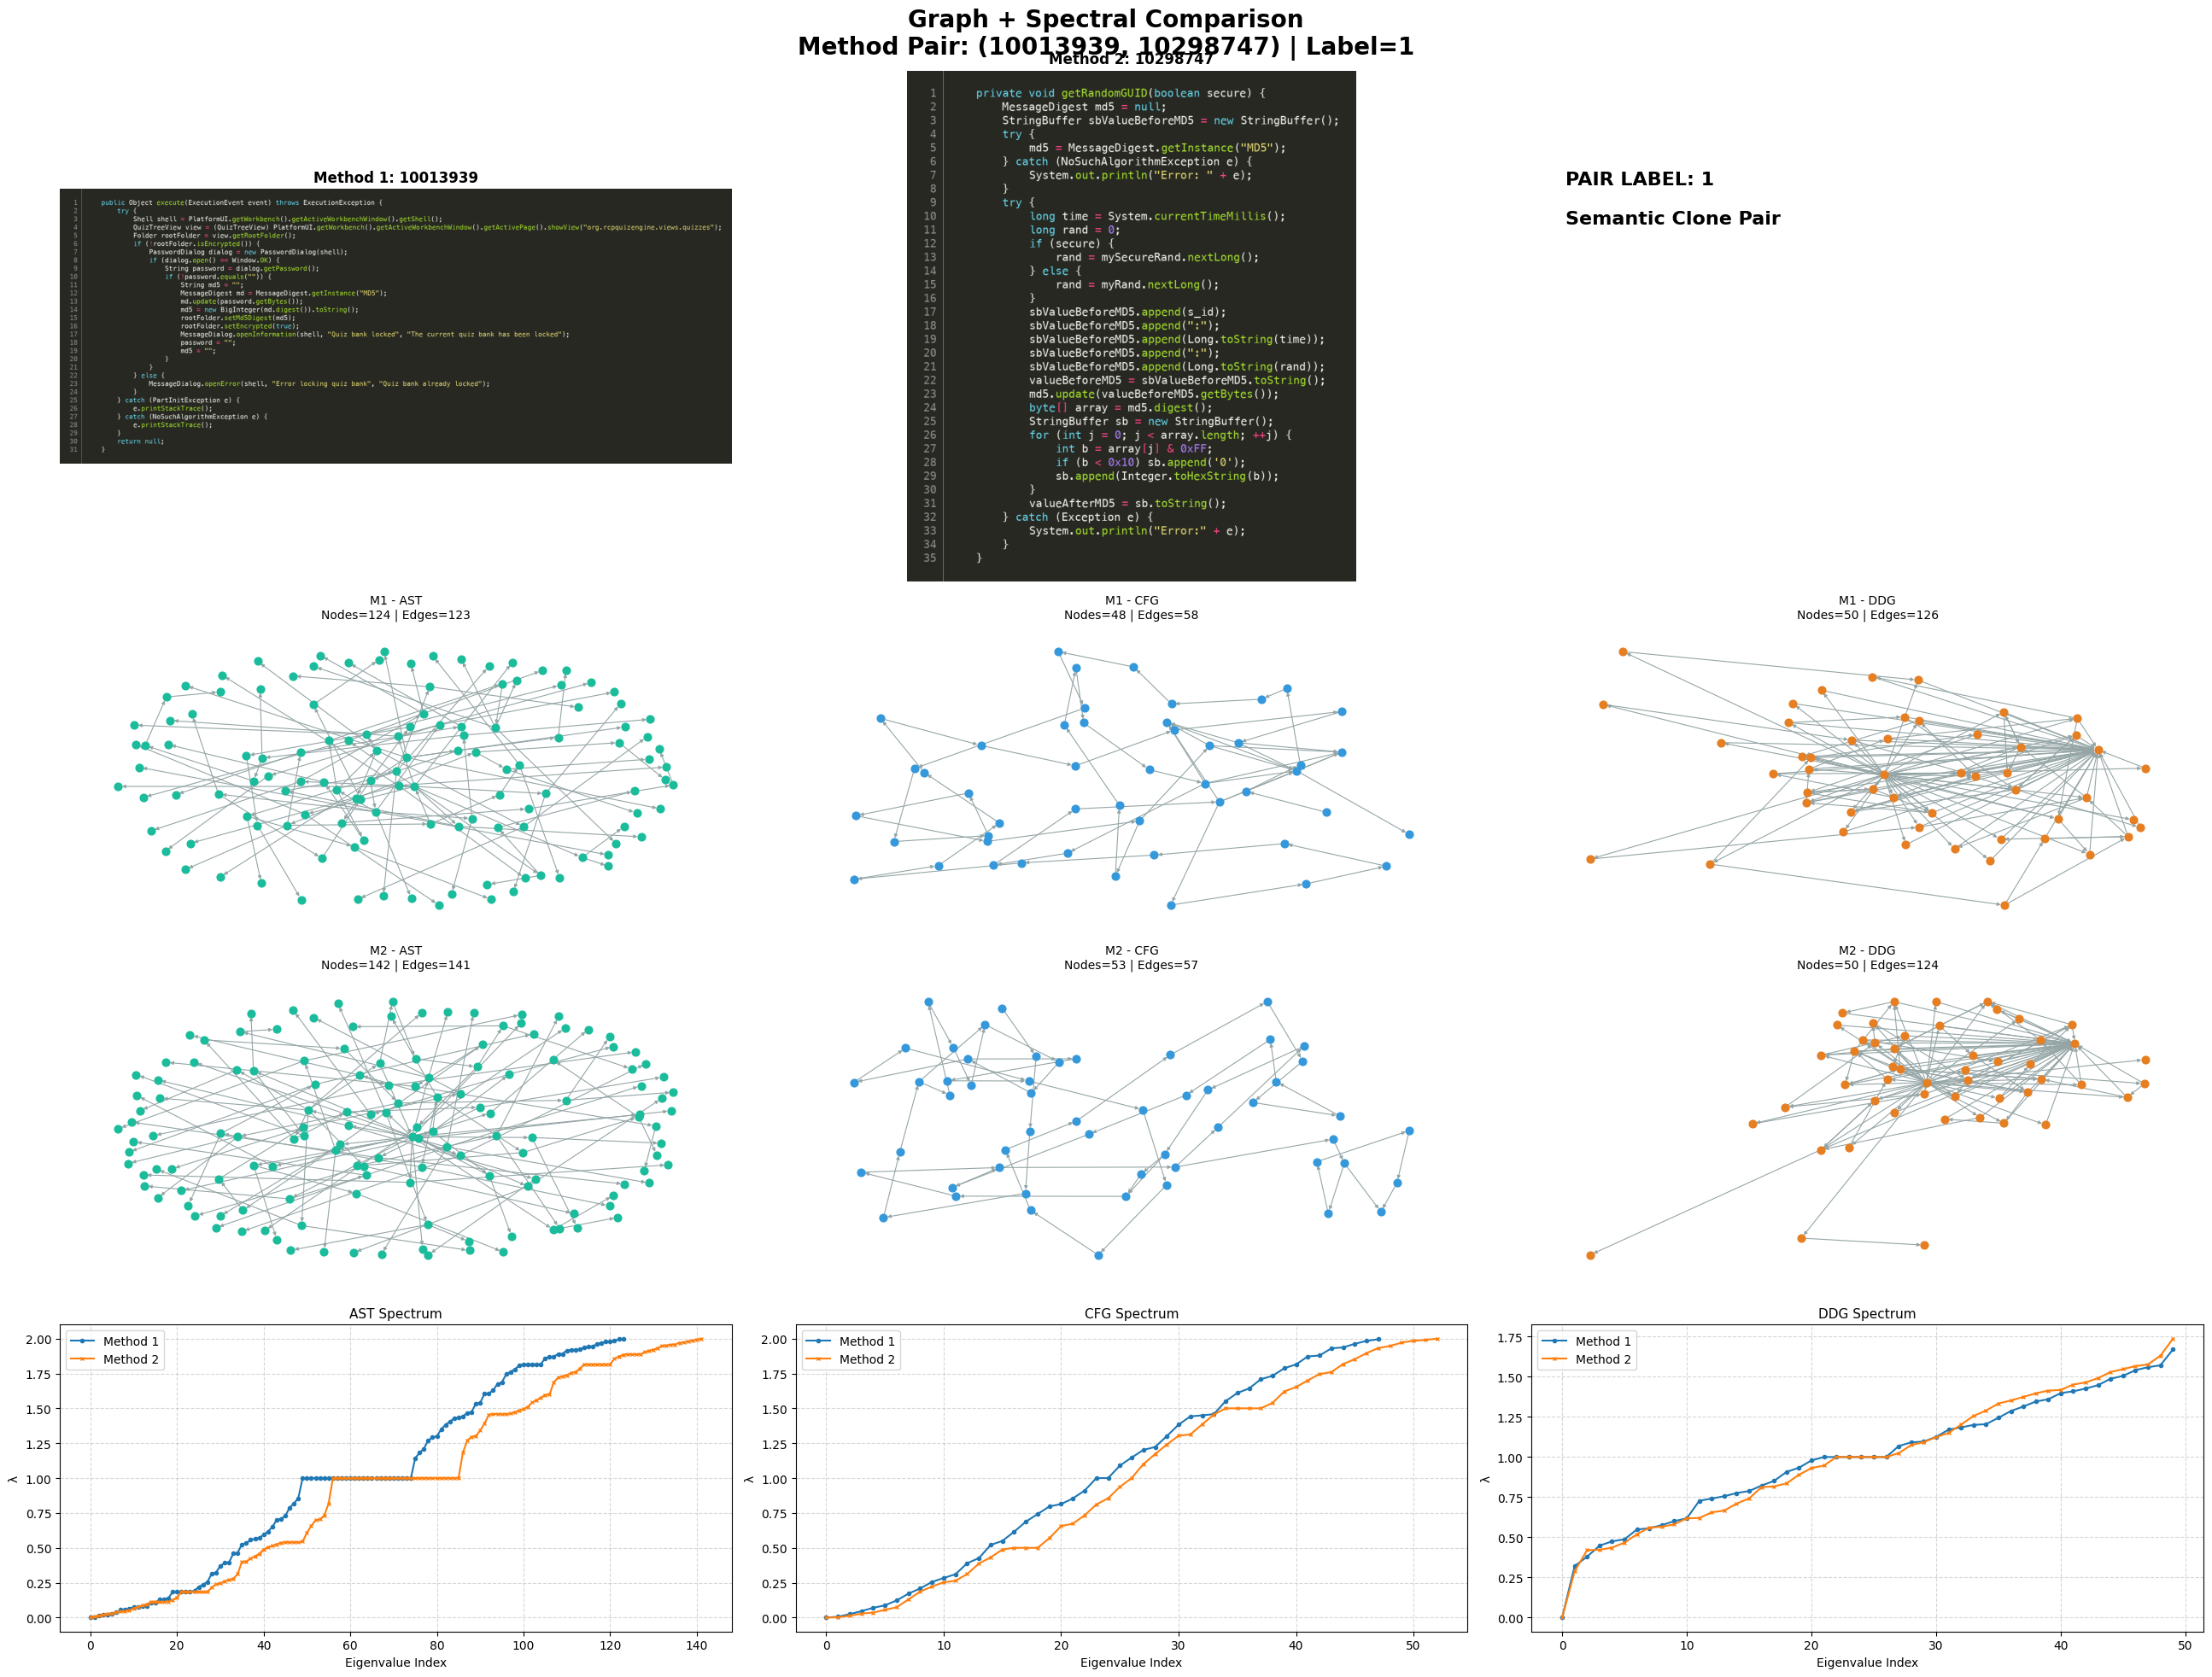

In [13]:
idx1 ='10013939'
idx2 = '10298747'
label = 1
visualize_method_pair(
    idx1,
    idx2,
    label,
    graph_db,
    features_db,
    code_map,
)

Selected Pair
Method 1: 21454371
Method 2: 8567304
Label    : 1


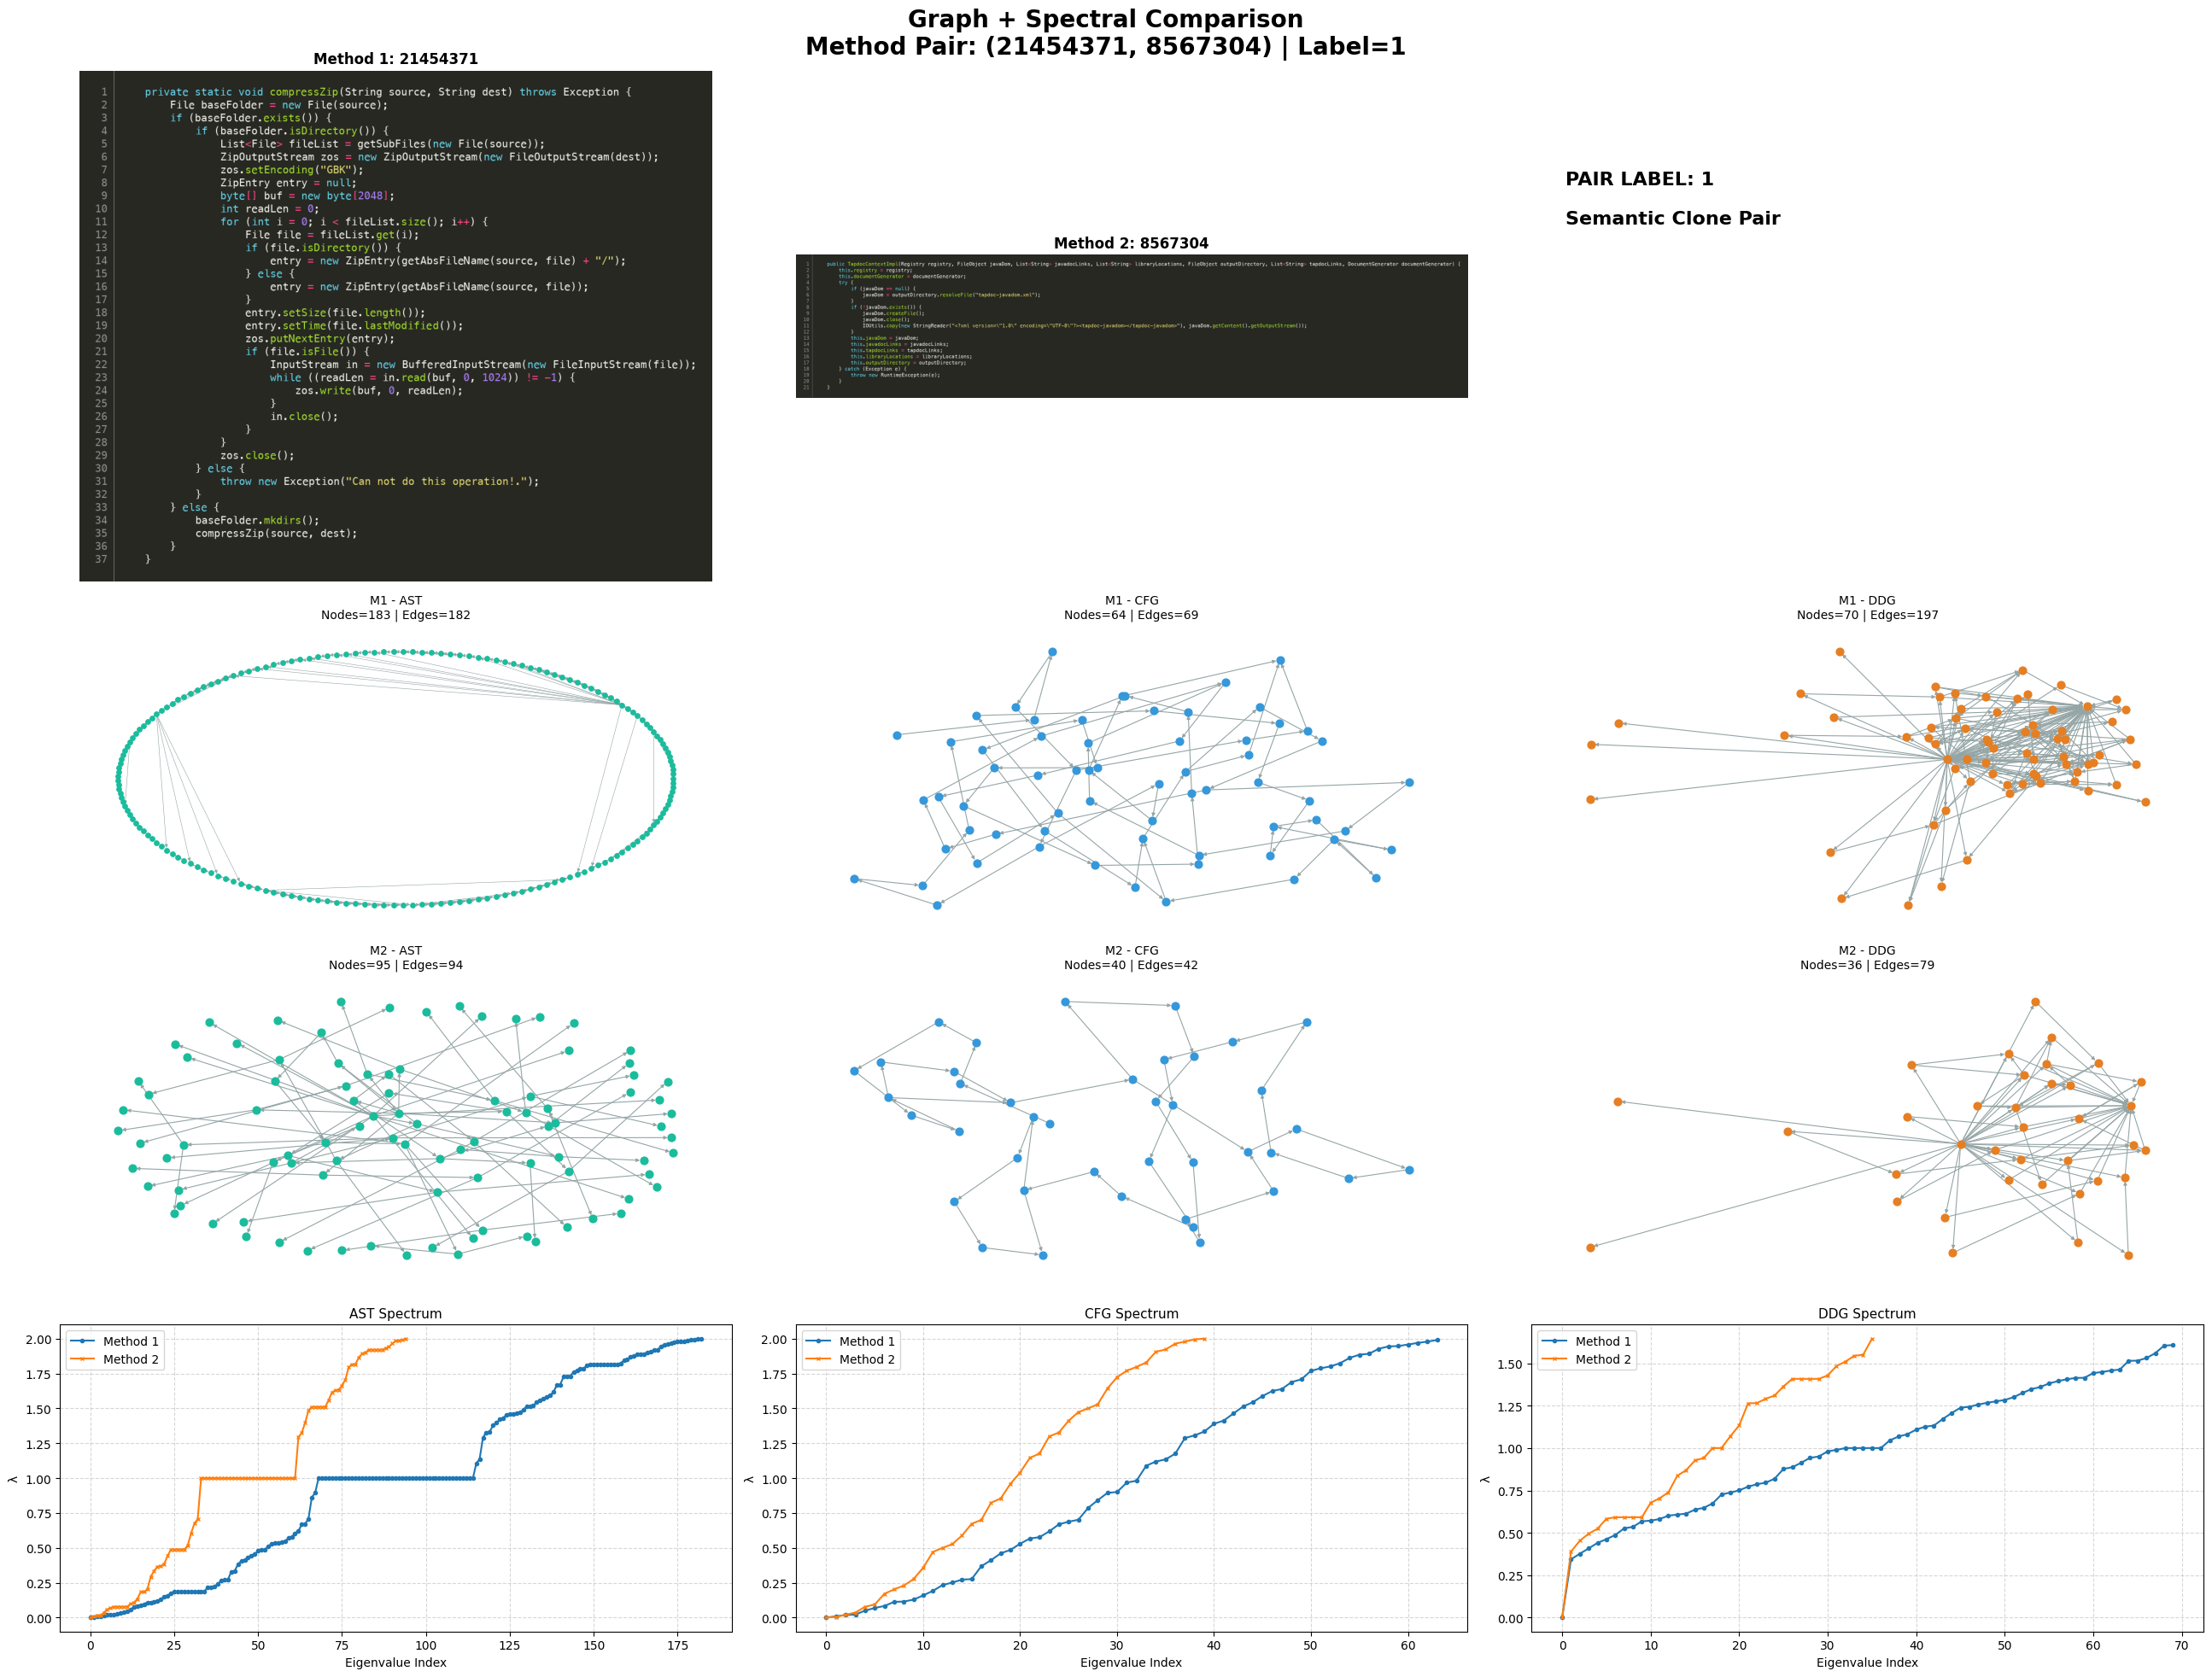

In [14]:
visualize_random_pair(
    train_pairs,
    graph_db,
    features_db,
    code_map,
)

                 GRAPH DATABASE SANITY CHECK
Layer      | Total Methods   | Empty (0 nodes) | Suspiciously Small   | Avg Nodes 
---------------------------------------------------------------------------
AST        | 8899            | 0               | 3 (<15 nodes)        | 154.0
CFG        | 8899            | 0               | 0 (<4 nodes)         | 59.5
DDG        | 8899            | 0               | 0 (<4 nodes)         | 57.6
PDG        | 8899            | 0               | 0 (<4 nodes)         | 61.9


**********************************************************************
>>> VISUALIZING ABNORMAL AST GRAPHS (Sample) <<<
**********************************************************************

--- Method ID: 19532000 | AST Nodes: 12 ---
Source Code:
static MenuListener openRecentHandler() {
        MenuListener handler = new MenuListener() {

            public void menuSelected(final MenuEvent event) {
                final JMenu menu = (JMenu) event.getSource();
                m

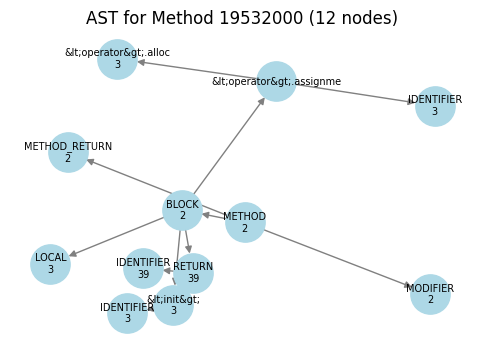


--- Method ID: 5231290 | AST Nodes: 14 ---
Source Code:
private void doDecrypt() {
        runningThread = new Thread() {

            @Override
            public void run() {
                Application.getController().notifyProgressStarted();
                Application.getController().notifyProgressUpdated(-1);
                for (int f = 0; f < fileList.size(); f++) {
                    File archive = fileList.get(f);
                    String arname = archive.getName();
                    String arsuf = arname.substring(arname.lastIndexOf('.'), arname.length());
                    Algorithm alg = null;
                    Algorithm algs[] = algFactory.getAlgorithms();
                    for (int i = 0; i < algs.length; i++) {
                        if (algs[i].getSuffix().equalsIgnoreCase(arsuf)) {
                            alg = algs[i];
                            break;
                        }
                    }
                    if (alg == null) {
           

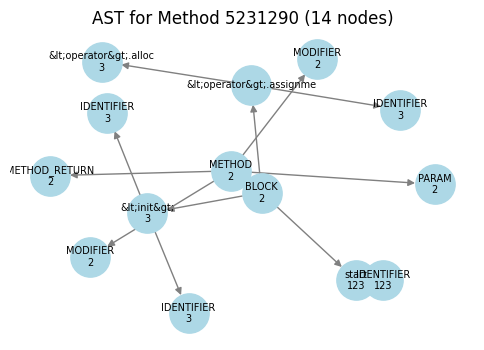


[+] No suspiciously small graphs found for CFG.

[+] No suspiciously small graphs found for DDG.

[+] No suspiciously small graphs found for PDG.


In [15]:
import json
import random
import matplotlib.pyplot as plt
import networkx as nx

if 'graph_db' in locals():
    layers = ['ast', 'cfg', 'ddg', 'pdg']
    
    # Threshold for suspicious graphs
    thresholds = {'ast': 15, 'cfg': 4, 'ddg': 4, 'pdg': 4}
    
    stats = {layer: {'total': 0, 'empty': 0, 'small': 0, 'small_mids': [], 'total_nodes': 0} for layer in layers}
    
    # 1. Statistics and Sanity Check
    for mid, graphs in graph_db.items():
        for layer in layers:
            g = graphs.get(layer)
            if g is not None:
                n = g.number_of_nodes()
                stats[layer]['total'] += 1
                stats[layer]['total_nodes'] += n
                
                if n == 0:
                    stats[layer]['empty'] += 1
                elif n < thresholds[layer]:
                    stats[layer]['small'] += 1
                    stats[layer]['small_mids'].append(mid)
                    
    print("="*75)
    print("                 GRAPH DATABASE SANITY CHECK")
    print("="*75)
    print(f"{'Layer':<10} | {'Total Methods':<15} | {'Empty (0 nodes)':<15} | {'Suspiciously Small':<20} | {'Avg Nodes':<10}")
    print("-" * 75)
    
    for layer in layers:
        s = stats[layer]
        avg = s['total_nodes'] / s['total'] if s['total'] > 0 else 0
        status_small = f"{s['small']} (<{thresholds[layer]} nodes)"
        print(f"{layer.upper():<10} | {s['total']:<15} | {s['empty']:<15} | {status_small:<20} | {avg:.1f}")
    print("="*75)
    
    snippets = {}
    try:
        with open('../data/data.jsonl', 'r', encoding='utf-8') as f:
            for line in f:
                entry = json.loads(line)
                snippets[str(entry.get('idx', ''))] = entry.get('func', 'No source available')
    except Exception as e:
        print(f"Could not load data.jsonl: {e}")

    layer_colors = {'ast': 'lightblue', 'cfg': 'lightgreen', 'ddg': 'lightsalmon', 'pdg': 'plum'}
    
    for layer in layers:
        s = stats[layer]
        if not s['small_mids']:
            print(f"\n[+] No suspiciously small graphs found for {layer.upper()}.")
            continue
            
        print(f"\n\n{'*'*70}")
        print(f">>> VISUALIZING ABNORMAL {layer.upper()} GRAPHS (Sample) <<<")
        print(f"{'*'*70}")
        
        sample_size = min(2, len(s['small_mids']))
        samples = random.sample(s['small_mids'], sample_size)
        
        for idx in samples:
            g = graph_db[idx].get(layer)
            n = g.number_of_nodes()
            
            print(f"\n--- Method ID: {idx} | {layer.upper()} Nodes: {n} ---")
            print(f"Source Code:\n{snippets.get(idx, 'Not found').strip()}")
            print(f"-" * 70)
            
            plt.figure(figsize=(6, 4))
            plt.title(f"{layer.upper()} for Method {idx} ({n} nodes)")
            
            pos = nx.spring_layout(g, seed=42)
            
            labels = {}
            for node, data in g.nodes(data=True):
                ntype = data.get('type', '')
                label = data.get('label', '')
                labels[node] = f"{ntype}\n{label}"[:25]
                
            nx.draw(g, pos, with_labels=True, labels=labels, 
                    node_color=layer_colors[layer], font_size=7, 
                    node_size=800, font_color='black', edge_color='gray', arrows=True)
            plt.show()
else:
    print("[-] graph_db not found. Please run graph extraction cell first.")

In [16]:
import json
import random
import matplotlib.pyplot as plt
import networkx as nx

if 'graph_db' in locals():
    # Focus on extremely small graphs (less than 7 nodes) for final check
    extremely_small = []
    
    for mid, graphs in graph_db.items():
        ast_g = graphs.get('ast')
        # Graphs with 1 to 6 nodes are suspicious
        if ast_g is not None and 0 < ast_g.number_of_nodes() < 7:
            extremely_small.append(mid)
            
    print(f"Total methods with extremely small AST (< 7 nodes): {len(extremely_small)}")
    
    # Select 3 samples for display
    sample_size = min(3, len(extremely_small))
    samples = random.sample(extremely_small, sample_size) if sample_size > 0 else []
    
    if samples:
        snippets = {}
        try:
            with open('../data/data.jsonl', 'r', encoding='utf-8') as f:
                for line in f:
                    entry = json.loads(line)
                    idx = str(entry.get('idx', ''))
                    if idx in samples:
                        snippets[idx] = entry.get('func', 'No source available')
        except Exception as e:
            print(f"Could not load data.jsonl: {e}")
            
        for idx in samples:
            ast_g = graph_db[idx].get('ast')
            cfg_g = graph_db[idx].get('cfg')
            
            print(f"\n{'!'*60}")
            print(f"SUSPICIOUS METHOD ID: {idx}")
            print(f"Nodes: AST={ast_g.number_of_nodes()} | CFG={cfg_g.number_of_nodes() if cfg_g else 0}")
            print(f"Source Code:\n{snippets.get(idx, 'Not found').strip()}")
            print(f"{'!'*60}")
            
            # Display AST and CFG side-by-side for verification
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
            
            # Draw AST
            pos1 = nx.spring_layout(ast_g, seed=42)
            nx.draw(ast_g, pos1, ax=ax1, with_labels=True, 
                    labels={n: d.get('label', '') for n,d in ast_g.nodes(data=True)},
                    node_color='lightblue', node_size=600, font_size=8)
            ax1.set_title(f"AST (Method {idx})")
            
            # Draw CFG
            if cfg_g:
                pos2 = nx.spring_layout(cfg_g, seed=42)
                nx.draw(cfg_g, pos2, ax=ax2, with_labels=True, 
                        labels={n: d.get('label', '') for n,d in cfg_g.nodes(data=True)},
                        node_color='lightgreen', node_size=600, font_size=8)
                ax2.set_title(f"CFG (Method {idx})")
            
            plt.show()
    else:
        print("[+] No extremely small graphs found. The fixes seem to have worked!")
else:
    print("graph_db not found.")

Total methods with extremely small AST (< 7 nodes): 0
[+] No extremely small graphs found. The fixes seem to have worked!
